In [1]:
#!pip install tqdm

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set()
import matplotlib.pyplot as plt

from sklearn import linear_model
import lightgbm as lgbm
import catboost

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import pipeline
import feature_eng
from importlib import reload

reload(feature_eng)
print(dir(feature_eng))

['FE_benchmark', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_rowwise_features', 'add_temporal_FE']


In [3]:
# Load data
X_train = pd.read_csv("data/X_train.csv", index_col="ROW_ID")
X_test = pd.read_csv("data/X_test.csv", index_col="ROW_ID")

y_train = pd.read_csv("data/y_train.csv", index_col="ROW_ID")
sample_submission = pd.read_csv("data/sample_submission.csv", index_col="ROW_ID")

### Features

In [4]:
# Add benchmark features
X_train, X_test, features = feature_eng.FE_benchmark(X_train, X_test)

# Add rowwise features
X_train, X_test, features = feature_eng.add_rowwise_features(X_train, X_test, features)

In [5]:
X_train[features].head()

,RET_1,RET_2,RET_3,RET_4,RET_5,RET_6,RET_7,RET_8,RET_9,RET_10,...,vol_max_20,vol_pos_count_20,vol_mean_3,vol_mean_5,vol_mean_10,vol_trend_1_minus_5,vol_trend_5_minus_20,ret5_x_turnover,vol5_x_turnover,absret20_to_turnover
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,0.003944,-0.000178,0.001013,0.001514,-0.009067,0.002864,-0.009116,0.003312,0.001350,-0.009898,...,1.208587,16,0.072136,0.086381,0.336413,NaN,-0.526921,-0.000054,0.008371,0.042611
1,0.002323,0.000670,0.001383,-0.003427,0.000577,0.003323,0.003926,0.002878,-0.000259,-0.000376,...,-0.636931,0,-0.733898,-0.794794,-1.100634,NaN,1.006714,0.000003,-0.007927,0.204580
2,-0.000238,-0.002696,-0.003926,-0.000569,-0.002528,0.004384,-0.011090,-0.002392,0.006396,-0.006482,...,1.669319,19,0.380808,0.736525,0.816540,NaN,-0.131491,-0.000088,0.032544,0.109356
3,0.001863,0.001234,-0.003304,-0.007703,-0.000645,0.002725,-0.000178,0.000003,0.002596,-0.006420,...,-0.349882,0,-0.718917,-0.929260,-0.732850,NaN,-0.106361,-0.000002,-0.001069,2.966929
4,0.001219,-0.001040,-0.002409,-0.004260,0.000723,0.008469,0.004208,0.009455,-0.000475,0.000226,...,3.112834,13,0.992271,1.278511,0.908251,NaN,0.737191,NaN,NaN,NaN


### Fitting a lightgbm using cross validation

In [7]:
print("lightgbm on bechmark + rowwise features and normal cv")
lgbm_models, lgbm_scores = pipeline.lgbm_cv(
    X_train,
    y_train,
    X_test,
    features,
    num_boost_round=500,
    learning_rate=0.05,
    max_depth=6,
    see_folds=True,
)

lightgbm on bechmark + rowwise features and normal cv
Fold 1 - Accuracy: 51.72%
Fold 2 - Accuracy: 52.12%
Fold 3 - Accuracy: 51.97%
Fold 4 - Accuracy: 52.01%
Fold 5 - Accuracy: 52.00%
Fold 6 - Accuracy: 52.20%
Fold 7 - Accuracy: 52.01%
Fold 8 - Accuracy: 51.74%
Accuracy: 51.97% [51.82 ; 52.13] (+- 0.16)


<Axes: >

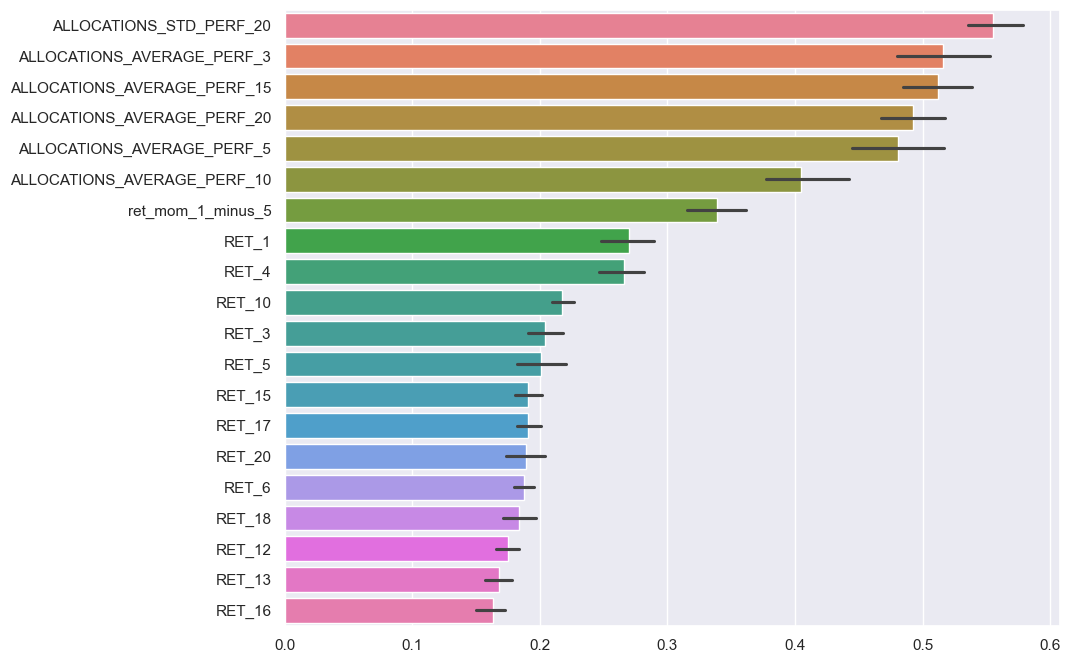

In [10]:
feature_importances = pd.DataFrame(
    [
        model_lgbm.feature_importance(importance_type="gain")
        for model_lgbm in lgbm_models
    ],
    columns=features,
)

feature_importances = feature_importances.loc[
    :, feature_importances.mean(0).sort_values(ascending=False).index[:20]
]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importances,
    orient="h",
    order=feature_importances.mean().sort_values(ascending=False).index,
)

In [14]:
import pipeline
from importlib import reload

reload(pipeline)
print(dir(pipeline))

['KFold', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'accuracy_score', 'catboost', 'catboost_cv', 'catboost_cv_temporal', 'feature_eng', 'find_hyperparameters_catboost', 'find_hyperparameters_lgbm', 'lgbm', 'lgbm_cv', 'lgbm_cv_temporal', 'linear_model', 'np', 'pd', 'plt', 'sns', 'train_catboost', 'train_lgbm', 'train_test_split']


In [15]:
# change to True to save the predictions in a csv file
pipeline.train_lgbm(X_train, y_train, X_test, features, saving_csv=False)

# fitting Catboost with CV

In [16]:
catboost_models, catboost_scores = pipeline.catboost_cv(
    X_train,
    y_train,
    features,
)

Accuracy: 51.96% [51.68 ; 52.24] (+- 0.28)


In [17]:
pipeline.train_catboost(X_train, y_train, features, saving_csv=True)

NameError: name 'X_test' is not defined

# Try to use the reconctructed 


In [ ]:
X_train_rec = pd.read_csv("data/X_train_reconstructed.csv", index_col="ROW_ID")

X_train, X_test, features = feature_eng.FE_benchmark(X_train_rec, X_test)
X_train, X_test, features = feature_eng.add_rowwise_features(X_train, X_test, features)
X_train, X_test, features = feature_eng.add_temporal_FE(X_train, X_test, features)

### lgbm temporal

In [ ]:
lgbm_models_temporal, lgbm_scores_temporal = pipeline.lgbm_cv_temporal(
    X_train,
    y_train,
    X_test,
    features,
    num_boost_round=500,
    learning_rate=0.05,
    max_depth=6,
    see_folds=True,
)

In [ ]:
def plot_feature_importances(models_lgbm, features_lgbm):
    feature_importances = pd.DataFrame(
        [
            model_lgbm.feature_importance(importance_type="gain")
            for model_lgbm in models_lgbm
        ],
        columns=features_lgbm,
    )

    feature_importances = feature_importances.loc[
        :, feature_importances.mean(0).sort_values(ascending=False).index[:20]
    ]

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=feature_importances,
        orient="h",
        order=feature_importances.mean().sort_values(ascending=False).index,
    )

In [ ]:
pipeline.train_lgbm_temporal(X_train, y_train, features, saving_csv=False)

## Catboost temporal

In [ ]:
catboost_models_temporal, catboost_scores_temporal = pipeline.catboost_cv_temporal(
    X_train,
    y_train,
    features,
)


In [ ]:
pipeline.train_catboost_temporal(X_train, y_train, features, saving_csv=False)